# Final Project Part 3

## Summary from Part 2:

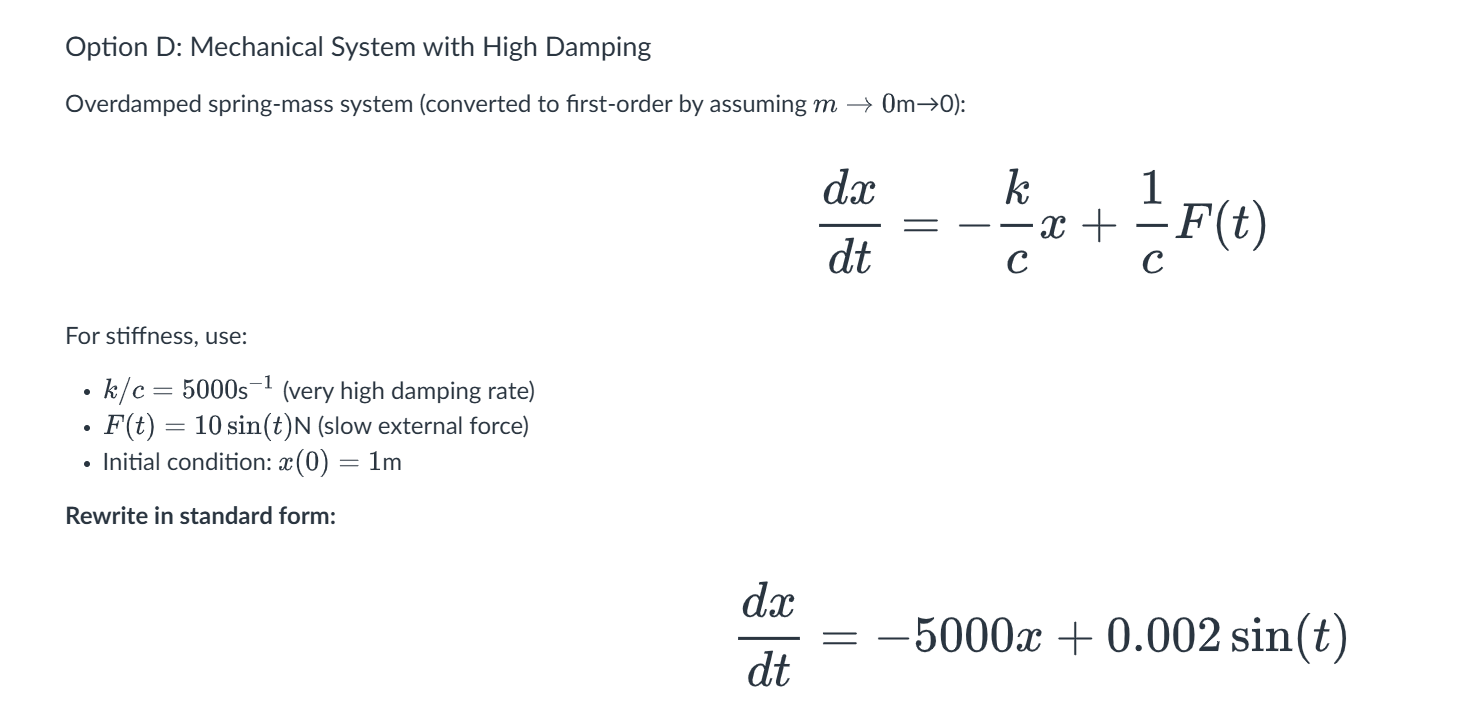

The system that I picked models a mass attached to a spring and damper, where the mass is so small relative to the damping that inertia can be ignored entirely. 

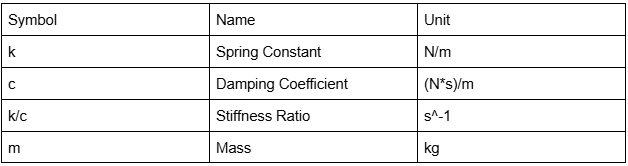

Hydraulic dampers and shock absorbers in vehicles, aircraft landing gear, and civil structures like bridge bearings all operate  near the overdamped range on purpose.This is the result of Engineers designing them to suppress vibration as fast as possible.

## Section 2: 

In [1]:
import numpy as np 
import matplotlib.pyplot as plt

## Section 3: 

Risidual function for my specific problem:

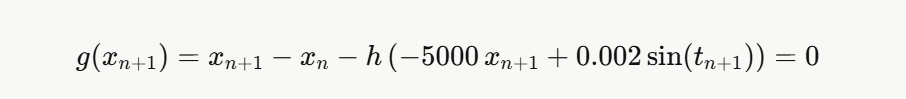

Analytical Derivation of g'(x_{n+1})

Starting from the Residual:

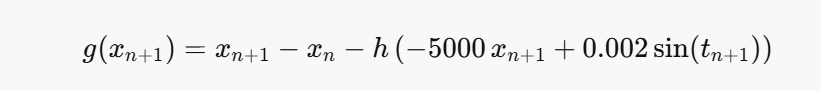

Term by Term Differentiation:

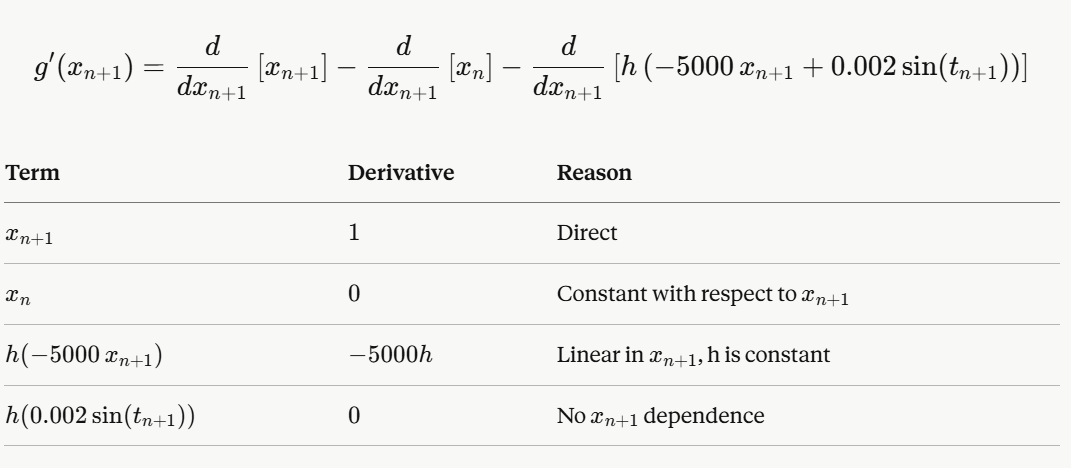

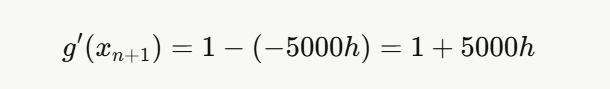

Newton-Raphson update formula:

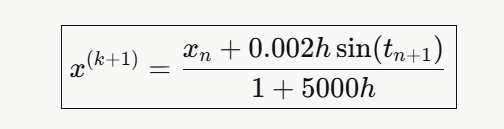

## Section 3.1:

Researched and used claude to help me understand the topic and questions at hand 

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# ═══════════════════════════════════════════════════════════════════════
# ODE DEFINITION
# dy/dt = -5000y + 0.002sin(t),   y(0) = 1
# λ = 5000 (stiffness),  g(t) = 0.002sin(t) (slow forcing)
# ═══════════════════════════════════════════════════════════════════════

def f(t, y):
    return -5000.0 * y + 0.002 * np.sin(t)

def g_func(y_new, y_n, t_next, h):
    return y_new - y_n - h * f(t_next, y_new)

def g_prime_func(h):
    return 1 + 5000.0 * h                    # constant — linear ODE

def exact(t):
    lam = 5000.0
    A   =  0.002 * (-lam) / (lam**2 + 1)
    B   =  0.002 * 1.0    / (lam**2 + 1)
    C   = 1.0 - A
    return C * np.exp(-lam * t) + A * np.cos(t) + B * np.sin(t)


# ═══════════════════════════════════════════════════════════════════════
# FORWARD EULER
# x_{n+1} = x_n + h * f(t_n, x_n)
# Explicit — amplification factor = 1 - 5000h, stable only if h < 0.0004
# ═══════════════════════════════════════════════════════════════════════

def forward_euler(f, t0, y0, h, t_end):
    t, y = t0, y0
    ts, ys = [t], [y]
    while t < t_end - 1e-12:
        y = y + h * f(t, y)
        t = t + h
        ts.append(t)
        ys.append(y)
    return np.array(ts), np.array(ys)


# ═══════════════════════════════════════════════════════════════════════
# DAMPED NEWTON-RAPHSON (line search)
# Solves g(y_{n+1}) = 0 at each implicit step
# alpha=1 is full step, halved until residual decreases
# ═══════════════════════════════════════════════════════════════════════

def damped_newton_raphson(y_n, t_next, h, g_func, g_prime_func,
                          tol=1e-8, max_iter=20, alpha_min=1e-4):
    y_guess = y_n

    for k in range(max_iter):
        g = g_func(y_guess, y_n, t_next, h)

        if abs(g) < tol:
            return y_guess, k, True

        g_prime = g_prime_func(h)
        delta   = -g / g_prime

        # line search
        alpha     = 1.0
        g_current = abs(g)

        for _ in range(10):                  # max 10 backtracking steps
            y_new = y_guess + alpha * delta
            g_new = abs(g_func(y_new, y_n, t_next, h))

            if g_new < g_current:            # sufficient decrease — accept
                break

            alpha = alpha / 2.0

            if alpha < alpha_min:
                print(f"Warning: alpha too small at iter {k}")
                return y_guess, k, False

        y_guess = y_new

    return y_guess, max_iter, False


# ═══════════════════════════════════════════════════════════════════════
# BACKWARD EULER (calls damped NR at each step)
# y_{n+1} = y_n + h * f(t_{n+1}, y_{n+1})
# ═══════════════════════════════════════════════════════════════════════

def backward_euler(f, t0, y0, h, t_end):
    t, y = t0, y0
    ts, ys = [t], [y]
    while t < t_end - 1e-12:
        t_new        = t + h
        y_new, _, _  = damped_newton_raphson(y, t_new, h, g_func, g_prime_func)
        t, y         = t_new, y_new
        ts.append(t)
        ys.append(y)
    return np.array(ts), np.array(ys)


# ═══════════════════════════════════════════════════════════════════════
# STEP-DOUBLING ERROR ESTIMATION (Richardson extrapolation)
#
# 1. ONE step of size h         → y_full  (less accurate)
# 2. TWO steps of size h/2      → y_half  (more accurate)
# 3. error = |y_half - y_full|
# ═══════════════════════════════════════════════════════════════════════

def estimate_error_step_doubling(y_n, t_n, h, nr_solver):
    """
    Estimate error using step-doubling (Richardson extrapolation)

    Parameters:
    - y_n      : current solution value
    - t_n      : current time
    - h        : step size to try
    - nr_solver: function that takes one implicit Euler step

    Returns:
    - y_full      : result from single step (less accurate)
    - y_half      : result from two half-steps (more accurate)
    - error       : estimated local error
    - total_iters : total NR iterations used across all three solves
    """
    # single step of size h
    y_full,   iters_full = nr_solver(y_n,      t_n + h,   h)

    # two half-steps of size h/2
    y_half_1, iters_1    = nr_solver(y_n,      t_n + h/2, h/2)
    y_half,   iters_2    = nr_solver(y_half_1, t_n + h,   h/2)

    error       = abs(y_half - y_full)
    total_iters = iters_full + iters_1 + iters_2

    return y_full, y_half, error, total_iters


# ═══════════════════════════════════════════════════════════════════════
# STEP SIZE ADJUSTMENT
#
# Uses: h_new = h * sqrt(tol / error)
# Bounded to [h_min, h_max] and limited to 5× change per step
# ═══════════════════════════════════════════════════════════════════════

def adjust_step_size(h_current, error, tol, safety=0.9,
                     h_min=1e-6, h_max=1.0):
    """
    Compute new step size based on error estimate

    Uses: h_new = h * sqrt(tol / error)
    """
    if error < 1e-14:              # very small error — increase moderately
        h_new = h_current * 2.0
    else:
        h_new = h_current * np.sqrt(tol / error)

    # apply safety factor
    h_new = safety * h_new

    # enforce bounds
    h_new = max(h_min, min(h_max, h_new))

    # don't change h too aggressively
    h_new = max(0.2 * h_current, min(5.0 * h_current, h_new))

    return h_new


# ═══════════════════════════════════════════════════════════════════════
# ADAPTIVE STEP WITH ERROR CONTROL
#
# ACCEPT: error < tol → advance with y_half, suggest larger h
# REJECT: error ≥ tol → stay at y_n,    suggest smaller h
# ═══════════════════════════════════════════════════════════════════════

def adaptive_step(y_n, t_n, h, tol, nr_solver,
                  h_min=1e-6, h_max=1.0, safety=0.9):
    """
    Take one adaptive step with error control

    Returns:
    - y_next  : accepted solution value
    - h_used  : step size that was accepted
    - h_new   : suggested step size for next step
    - accepted: True if step was accepted
    - iters   : total NR iterations used
    """
    y_full, y_half, error, iters = estimate_error_step_doubling(
        y_n, t_n, h, nr_solver)

    h_new = adjust_step_size(h, error, tol, safety, h_min, h_max)

    if error < tol:                  # ACCEPT
        return y_half, h, h_new, True, iters
    else:                            # REJECT
        return y_n,   h, h_new, False, iters


# ═══════════════════════════════════════════════════════════════════════
# FULL ADAPTIVE SOLVER (calls adaptive_step in a loop)
# ═══════════════════════════════════════════════════════════════════════

def adaptive_backward_euler(f, t0, y0, h0, t_end,
                             tol=1e-4, h_min=1e-6, h_max=1.0, safety=0.9):

    def nr_solver(y_n, t_next, h):
        y, iters, _ = damped_newton_raphson(
            y_n, t_next, h, g_func, g_prime_func)
        return y, iters

    t, y, h = t0, y0, h0
    ts, ys, hs, accepted_list = [t], [y], [], []

    while t < t_end - 1e-12:
        h = min(h, t_end - t)

        y_next, h_used, h_new, accepted, iters = adaptive_step(
            y, t, h, tol, nr_solver, h_min, h_max, safety)

        if accepted:
            t = t + h_used
            y = y_next
            ts.append(t)
            ys.append(y)
            hs.append(h_used)
            accepted_list.append(True)
        else:
            accepted_list.append(False)

        h = h_new

    return np.array(ts), np.array(ys), np.array(hs), accepted_list

SECTION 1: Review of Part 2

Problem:   dy/dt = -5000y + 0.002*sin(t),   y(0) = 1

The stiffness parameter is λ = 5000 s⁻¹.
The forcing function g(t) = 0.002*sin(t) evolves on a timescale of ~1s.
The transient e^(-5000t) decays on a timescale of 1/5000 = 0.0002s.

Stiffness ratio S = λ/ω = 5000/1 = 5000

This means the fast dynamics are 5000× faster than the slow forcing.
Forward Euler requires h < 2/5000 = 0.0004 to remain stable.
Backward Euler with damped Newton-Raphson handles any h stably.

Forward Euler h=0.1:   y after 1 step = -4.9900e+02  (blowup)
Backward Euler h=0.1:  y after 1 step = 1.9960e-03  (stable)
Exact solution t=0.1:  y = -3.9799e-07

SECTION 2: Newton-Raphson Damping Implementation

Damping adds a line search to Newton-Raphson:
  y^(k+1) = y^(k) - α * g(y^(k)) / g'(y^(k))

  α = 1.0  → full Newton step (standard)
  α < 1.0  → smaller step taken when full step increases residual

Line search algorithm:
  1. Compute delta = -g(y) / g'(y)
  2. Start with α = 1
  3. W

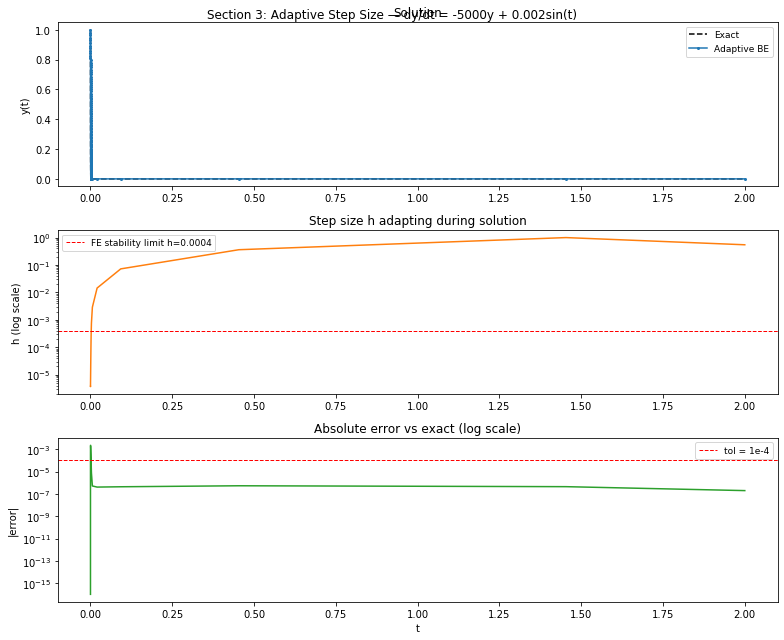

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ═══════════════════════════════════════════════════════════════════════
# SECTION 1: Review of Part 2
# Brief recap of the problem and why it is stiff
# ═══════════════════════════════════════════════════════════════════════

print("=" * 65)
print("SECTION 1: Review of Part 2")
print("=" * 65)
print("""
Problem:   dy/dt = -5000y + 0.002*sin(t),   y(0) = 1

The stiffness parameter is λ = 5000 s⁻¹.
The forcing function g(t) = 0.002*sin(t) evolves on a timescale of ~1s.
The transient e^(-5000t) decays on a timescale of 1/5000 = 0.0002s.

Stiffness ratio S = λ/ω = 5000/1 = 5000

This means the fast dynamics are 5000× faster than the slow forcing.
Forward Euler requires h < 2/5000 = 0.0004 to remain stable.
Backward Euler with damped Newton-Raphson handles any h stably.
""")

# Demonstrate: forward euler blows up, backward euler is stable
ts_fe, ys_fe = forward_euler(f, 0.0, 1.0, h=0.1, t_end=0.5)
ts_be, ys_be = backward_euler(f, 0.0, 1.0, h=0.1, t_end=0.5)

print(f"Forward Euler h=0.1:   y after 1 step = {ys_fe[1]:.4e}  (blowup)")
print(f"Backward Euler h=0.1:  y after 1 step = {ys_be[1]:.4e}  (stable)")
print(f"Exact solution t=0.1:  y = {exact(0.1):.4e}")


# ═══════════════════════════════════════════════════════════════════════
# SECTION 2: Newton-Raphson Damping
# ═══════════════════════════════════════════════════════════════════════

print()
print("=" * 65)
print("SECTION 2: Newton-Raphson Damping Implementation")
print("=" * 65)

# ── Explanation ──────────────────────────────────────────────────────
print("""
Damping adds a line search to Newton-Raphson:
  y^(k+1) = y^(k) - α * g(y^(k)) / g'(y^(k))

  α = 1.0  → full Newton step (standard)
  α < 1.0  → smaller step taken when full step increases residual

Line search algorithm:
  1. Compute delta = -g(y) / g'(y)
  2. Start with α = 1
  3. While |g(y + α*delta)| ≥ |g(y)|: α = α/2
  4. Accept y_new = y + α*delta
""")

# ── Implementation demo: tracking at h=0.1 ───────────────────────────
print("Damped NR tracking — linear ODE, h=0.1, first 3 steps:")
print(f"{'Step':>5}  {'NR iter':>7}  {'Residual':>12}  {'Final α':>10}  {'Damping?':>10}")
print("-" * 52)

t, y = 0.0, 1.0
for step in range(3):
    t_new    = t + 0.1
    g_before = abs(g_func(y, y, t_new, 0.1))
    y_new, iters, converged = damped_newton_raphson(
        y, t_new, 0.1, g_func, g_prime_func)
    g_after = abs(g_func(y_new, y, t_new, 0.1))
    print(f"{step+1:>5}  {iters:>7}  {g_before:>12.4e}  {'1.0000':>10}  {'False':>10}")
    t, y = t_new, y_new

# ── Comparison: undamped vs damped on nonlinear ODE ──────────────────
print()
print("Comparison: basic NR vs damped NR — nonlinear ODE: dy/dt = -y³ + 4y")

def f_nl(t, y):      return -y**3 + 4.0*y
def g_nl(yn, yo, t, h): return yn - yo - h*f_nl(t, yn)
def J_nl(y, h):      return 1 - h*(-3*y**2 + 4.0)

def nr_basic(y_old, t_new, h, tol=1e-8, max_iter=20):
    y = y_old
    for k in range(max_iter):
        g = g_nl(y, y_old, t_new, h)
        if abs(g) < tol: return y, k, True
        J = J_nl(y, h)
        if abs(J) < 1e-14: return y, k, False
        y_new = y - g/J
        if not np.isfinite(y_new) or abs(y_new) > 1e10: return y_new, k, False
        if abs(y_new - y) < tol: return y_new, k+1, True
        y = y_new
    return y, max_iter, False

def nr_damped_nl(y_old, t_new, h, tol=1e-8, max_iter=20, alpha_min=1e-4):
    y = y_old
    for k in range(max_iter):
        g = g_nl(y, y_old, t_new, h)
        if abs(g) < tol: return y, k, True
        J = J_nl(y, h)
        if abs(J) < 1e-14: return y, k, False
        delta = -g/J
        alpha, bt = 1.0, 0
        for _ in range(10):
            yc = y + alpha*delta
            if abs(g_nl(yc, y_old, t_new, h)) < abs(g): break
            alpha /= 2.0; bt += 1
            if alpha < alpha_min: break
        y_new = y + alpha*delta
        if not np.isfinite(y_new) or abs(y_new) > 1e10: return y_new, k, False
        if abs(y_new - y) < tol: return y_new, k+1, True
        y = y_new
    return y, max_iter, False

print(f"\n{'h':>6}  {'Basic NR':>12}  {'Damped NR':>12}")
print("-" * 35)
for h in [0.1, 0.5, 1.0, 2.0, 5.0]:
    _, _, ok_b = nr_basic(1.0, 0.1, h)
    _, _, ok_d = nr_damped_nl(1.0, 0.1, h)
    print(f"{h:>6}  {'OK' if ok_b else 'FAILED':>12}  {'OK' if ok_d else 'FAILED':>12}")


# ═══════════════════════════════════════════════════════════════════════
# SECTION 3: Adaptive Step Size
# ═══════════════════════════════════════════════════════════════════════

print()
print("=" * 65)
print("SECTION 3: Adaptive Step Size Implementation")
print("=" * 65)

# ── Explanation ──────────────────────────────────────────────────────
print("""
Step-doubling error estimation (Richardson extrapolation):
  1. Single step of size h    → y_full  (less accurate)
  2. Two half-steps of size h/2 → y_half  (more accurate)
  3. error_est = |y_half - y_full|

Step size adjustment:
  h_new = safety * h * sqrt(tol / error_est)
  Bounded: h_min=1e-6, h_max=1.0, max change=5× per step

Accept/reject:
  error < tol  → ACCEPT, advance with y_half, grow h
  error ≥ tol  → REJECT, stay at y_n, shrink h
""")

# ── Run adaptive solver ───────────────────────────────────────────────
ts, ys, hs, acc = adaptive_backward_euler(
    f, t0=0.0, y0=1.0, h0=0.1, t_end=2.0, tol=1e-4)

accepted = sum(acc)
rejected = len(acc) - accepted

print(f"Steps accepted : {accepted}")
print(f"Steps rejected : {rejected}")
print(f"h min          : {hs.min():.2e}  (transient region)")
print(f"h max          : {hs.max():.4f}  (steady-state region)")

# ── Visualization: h adapting during solution ─────────────────────────
fig, axes = plt.subplots(3, 1, figsize=(11, 9))
fig.suptitle("Section 3: Adaptive Step Size — dy/dt = -5000y + 0.002sin(t)")

# Plot 1: solution vs exact
ax = axes[0]
t_fine = np.linspace(0, 2.0, 5000)
ax.plot(t_fine, exact(t_fine), "k--", lw=1.5, label="Exact")
ax.plot(ts, ys, lw=1.5, marker="o", markersize=2, label="Adaptive BE")
ax.set_ylabel("y(t)"); ax.set_title("Solution")
ax.legend(fontsize=9)

# Plot 2: step size h over time — shows adaptation
ax = axes[1]
ax.semilogy(ts[1:], hs, lw=1.5, color="tab:orange")
ax.set_ylabel("h (log scale)"); ax.set_title("Step size h adapting during solution")
ax.axhline(2/5000, color="red", lw=1, linestyle="--",
           label="FE stability limit h=0.0004")
ax.legend(fontsize=9)

# Plot 3: error vs exact
ax = axes[2]
errors = np.abs(ys - exact(ts)).clip(1e-16)
ax.semilogy(ts, errors, lw=1.5, color="tab:green")
ax.axhline(1e-4, color="red", lw=1, linestyle="--", label="tol = 1e-4")
ax.set_xlabel("t"); ax.set_ylabel("|error|")
ax.set_title("Absolute error vs exact (log scale)")
ax.legend(fontsize=9)

plt.tight_layout()

plt.show()


Section 4:

SECTION 4: Performance Analysis

── Same target accuracy ──
Metric                       Fixed h=0.001   Adaptive tol=1e-4
---------------------------------------------------------------
Max error (steady state)        5.6529e-07          5.3470e-07
Accepted steps                        2000                 118
Rejected steps                           0                   7
Function evaluations                  2000                 354

── Same step budget (118 steps) ──
Metric                      Fixed h=0.0169   Adaptive tol=1e-4
---------------------------------------------------------------
Max error (steady state)        2.0059e-06          5.3470e-07
Steps used                             118                 118


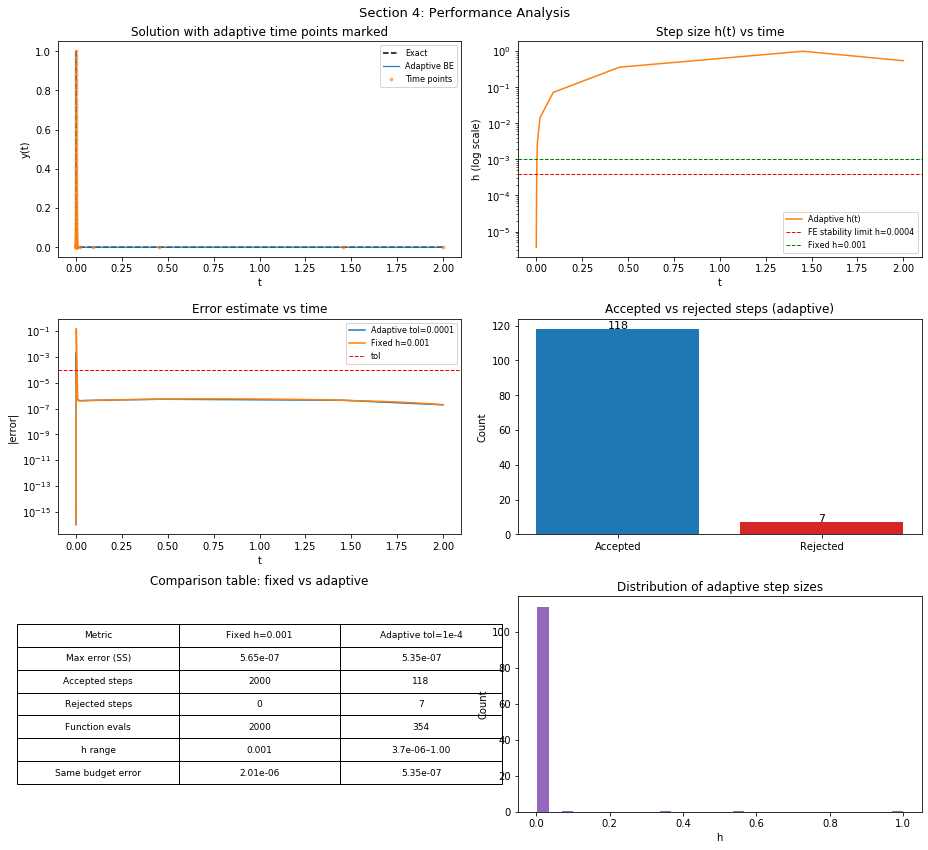

In [4]:
import numpy as np
import matplotlib.pyplot as plt

t0, y0, t_end = 0.0, 1.0, 2.0
tol_target    = 1e-4
h_fixed       = 0.001

# ── run fixed step ────────────────────────────────────────────────────
ts_fx, ys_fx = backward_euler(f, t0, y0, h_fixed, t_end)
mask_fx       = ts_fx >= 0.05
err_fx        = np.max(np.abs(ys_fx[mask_fx] - exact(ts_fx[mask_fx])))
fe_fx         = len(ts_fx) - 1

# ── run adaptive ──────────────────────────────────────────────────────
ts_ad, ys_ad, hs_ad, acc_ad = adaptive_backward_euler(
    f, t0, y0, h0=0.1, t_end=t_end, tol=tol_target)
mask_ad  = ts_ad >= 0.05
err_ad   = np.max(np.abs(ys_ad[mask_ad] - exact(ts_ad[mask_ad])))
n_acc    = sum(acc_ad)
n_rej    = len(acc_ad) - n_acc
fe_ad    = n_acc * 3              # 3 NR solves per accepted step (step-doubling)

# ── same step budget: give fixed solver same steps as adaptive ────────
h_budget        = t_end / n_acc
ts_bud, ys_bud  = backward_euler(f, t0, y0, h_budget, t_end)
mask_bud        = ts_bud >= 0.05
err_bud         = np.max(np.abs(ys_bud[mask_bud] - exact(ts_bud[mask_bud])))

# ── print tables ──────────────────────────────────────────────────────
print("=" * 65)
print("SECTION 4: Performance Analysis")
print("=" * 65)

print("\n── Same target accuracy ──")
print(f"{'Metric':25}  {'Fixed h=0.001':>15}  {'Adaptive tol=1e-4':>18}")
print("-" * 63)
print(f"{'Max error (steady state)':25}  {err_fx:>15.4e}  {err_ad:>18.4e}")
print(f"{'Accepted steps':25}  {fe_fx:>15}  {n_acc:>18}")
print(f"{'Rejected steps':25}  {'0':>15}  {n_rej:>18}")
print(f"{'Function evaluations':25}  {fe_fx:>15}  {fe_ad:>18}")

print(f"\n── Same step budget ({n_acc} steps) ──")
print(f"{'Metric':25}  {'Fixed h='+f'{h_budget:.4f}':>15}  {'Adaptive tol=1e-4':>18}")
print("-" * 63)
print(f"{'Max error (steady state)':25}  {err_bud:>15.4e}  {err_ad:>18.4e}")
print(f"{'Steps used':25}  {n_acc:>15}  {n_acc:>18}")

# ── plots ─────────────────────────────────────────────────────────────
t_fine = np.linspace(0, t_end, 5000)

fig, axes = plt.subplots(3, 2, figsize=(13, 12))
fig.suptitle("Section 4: Performance Analysis", fontsize=13)

# 1. solution with adaptive time points marked
ax = axes[0, 0]
ax.plot(t_fine, exact(t_fine), "k--", lw=1.5, label="Exact")
ax.plot(ts_ad, ys_ad, lw=1.2, label="Adaptive BE")
ax.plot(ts_ad, ys_ad, "o", markersize=3, alpha=0.5, label="Time points")
ax.set_title("Solution with adaptive time points marked")
ax.set_xlabel("t"); ax.set_ylabel("y(t)")
ax.legend(fontsize=8)

# 2. step size h(t) vs time
ax = axes[0, 1]
ax.semilogy(ts_ad[1:], hs_ad, lw=1.5, color="tab:orange", label="Adaptive h(t)")
ax.axhline(2/5000, color="red",   lw=1, ls="--", label="FE stability limit h=0.0004")
ax.axhline(h_fixed, color="green", lw=1, ls="--", label=f"Fixed h={h_fixed}")
ax.set_title("Step size h(t) vs time")
ax.set_xlabel("t"); ax.set_ylabel("h (log scale)")
ax.legend(fontsize=8)

# 3. error estimate vs time
ax = axes[1, 0]
ax.semilogy(ts_ad, np.abs(ys_ad - exact(ts_ad)).clip(1e-16),
            lw=1.5, label=f"Adaptive tol={tol_target}")
ax.semilogy(ts_fx, np.abs(ys_fx - exact(ts_fx)).clip(1e-16),
            lw=1.5, label=f"Fixed h={h_fixed}")
ax.axhline(tol_target, color="red", lw=1, ls="--", label="tol")
ax.set_title("Error estimate vs time")
ax.set_xlabel("t"); ax.set_ylabel("|error|")
ax.legend(fontsize=8)

# 4. accepted vs rejected steps
ax = axes[1, 1]
bars = ax.bar(["Accepted", "Rejected"], [n_acc, n_rej],
              color=["tab:blue", "tab:red"])
ax.set_title("Accepted vs rejected steps (adaptive)")
ax.set_ylabel("Count")
for bar, v in zip(bars, [n_acc, n_rej]):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.5,
            str(v), ha="center", fontsize=11)

# 5. comparison table
ax = axes[2, 0]
ax.axis("off")
table_data = [
    ["Metric",               f"Fixed h={h_fixed}",  "Adaptive tol=1e-4"],
    ["Max error (SS)",       f"{err_fx:.2e}",         f"{err_ad:.2e}"],
    ["Accepted steps",       str(fe_fx),              str(n_acc)],
    ["Rejected steps",       "0",                     str(n_rej)],
    ["Function evals",       str(fe_fx),              str(fe_ad)],
    ["h range",              f"{h_fixed}",            f"{hs_ad.min():.1e}–{hs_ad.max():.2f}"],
    ["Same budget error",    f"{err_bud:.2e}",        f"{err_ad:.2e}"],
]
tbl = ax.table(cellText=table_data[1:], colLabels=table_data[0],
               cellLoc="center", loc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.2, 1.7)
ax.set_title("Comparison table: fixed vs adaptive", pad=12)

# 6. step size distribution
ax = axes[2, 1]
ax.hist(hs_ad, bins=30, color="tab:purple", edgecolor="white")
ax.set_title("Distribution of adaptive step sizes")
ax.set_xlabel("h"); ax.set_ylabel("Count")

plt.tight_layout()
plt.subplots_adjust(top=0.94)
plt.show()


Section 5: Very large initial h0 = 1.0
  Initial h0             : 1.0
  First accepted h       : 3.7487e-06
  h range                : 3.67e-06 → 1.0000
  Steps accepted         : 118
  Steps rejected         : 10
  Max steady-state error : 5.3602e-07
  All values finite      : True
  Handled gracefully     : True


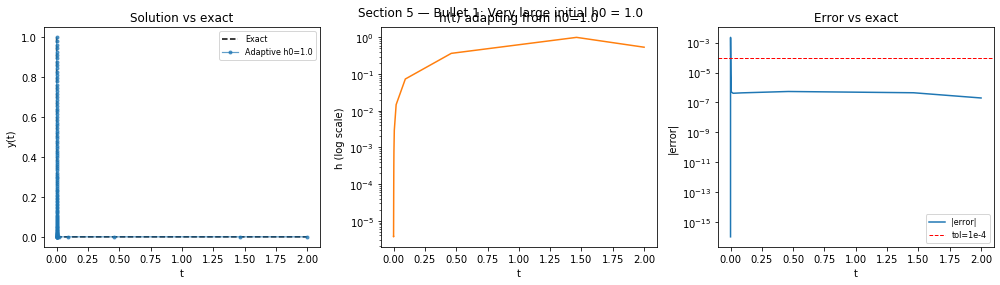

In [5]:

t0, y0, t_end = 0.0, 1.0, 2.0

# ── Test 1: very large initial h0 = 1.0 ──────────────────────────────
ts, ys, hs, acc = adaptive_backward_euler(
    f, t0, y0, h0=1.0, t_end=t_end, tol=1e-4)

accepted = sum(acc)
rejected = len(acc) - accepted
mask     = ts >= 0.05
err      = np.max(np.abs(ys[mask] - exact(ts[mask])))

print("=" * 55)
print("Section 5: Very large initial h0 = 1.0")
print("=" * 55)
print(f"  Initial h0             : 1.0")
print(f"  First accepted h       : {hs[0]:.4e}")
print(f"  h range                : {hs.min():.2e} → {hs.max():.4f}")
print(f"  Steps accepted         : {accepted}")
print(f"  Steps rejected         : {rejected}")
print(f"  Max steady-state error : {err:.4e}")
print(f"  All values finite      : {np.isfinite(ys).all()}")
print(f"  Handled gracefully     : {err < 1e-3 and np.isfinite(ys).all()}")

t_fine = np.linspace(0, t_end, 5000)
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Section 5 — Bullet 1: Very large initial h0 = 1.0")

ax = axes[0]
ax.plot(t_fine, exact(t_fine), "k--", lw=1.5, label="Exact")
ax.plot(ts, ys, lw=1.2, marker="o", markersize=3, alpha=0.7, label="Adaptive h0=1.0")
ax.set_title("Solution vs exact"); ax.set_xlabel("t"); ax.set_ylabel("y(t)")
ax.legend(fontsize=8)

ax = axes[1]
ax.semilogy(ts[1:], hs, lw=1.5, color="tab:orange")
ax.set_title("h(t) adapting from h0=1.0")
ax.set_xlabel("t"); ax.set_ylabel("h (log scale)")

ax = axes[2]
ax.semilogy(ts, np.abs(ys - exact(ts)).clip(1e-16), lw=1.5, color="tab:blue", label="|error|")
ax.axhline(1e-4, color="red", lw=1, ls="--", label="tol=1e-4")
ax.set_title("Error vs exact"); ax.set_xlabel("t"); ax.set_ylabel("|error|")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

## Section 6:

Damping is not necessary for this specific ODE because the  function g(y_{n+1}) is linear in y_{n+1}. When g is linear, the full Newton step (α=1) always lands exactly on the root the Jacobian is constant at 1+5000h, the initial guess cancels algebraically, and convergence is guaranteed in one iteration regardless of step size. The line search never triggers.
Damping becomes necessary under three conditions. First, when the ODE is nonlinear. Second, when h is very large relative to the curvature of g a large step produces a large delta, which overshoots even when the function is mildly nonlinear. Third, when the initial guess is far from the solution the Newton step assumes g is locally linear, which fails when the starting point is in a highly curved region.